# I-SPY2 External Validation of Paclitaxel Pathway Findings

Checks whether the Hallmark pathways associated with paclitaxel response in the PDX multi-omics case study (`3-figures.ipynb`, RNA GSEA) show a consistent direction of association with pathologic complete response (pCR) in a real clinical cohort: the **paclitaxel-monotherapy control arm of the I-SPY2 trial** (n=179), using the I-SPY2-990 Data Resource (Wolf et al. 2022, *Cancer Cell* 40:609-629, [doi:10.1016/j.ccell.2022.05.005](https://doi.org/10.1016/j.ccell.2022.05.005)).

Source files (`data/rawdata/I-SPY2/`): `mmc2.xlsx` (Table S1, biomarker definitions), `mmc3.xlsx` (Table S2, patient-level scores + clinical/response data), `mmc4.xlsx` (Table_S3, published per-arm pCR-association statistics).

## Imports and paths

In [1]:
from pathlib import Path
import io
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# Same theme/rcParams as the rest of this case study (3-figures.ipynb), so this
# figure renders with the same font and style as the others.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

from pipeline_utils import make_case4_paths

paths = make_case4_paths()
ISPY2_DIR = paths["data"] / "rawdata" / "I-SPY2"
RESULTS_DIR = paths["results"]
FIGURE_DIR = paths["figures"]

print(f"I-SPY2 raw data: {ISPY2_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Figures directory: {FIGURE_DIR}")


def savefig(name):
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    plt.savefig(png_path, bbox_inches="tight", dpi=300)
    plt.savefig(pdf_path, bbox_inches="tight")
    print("saved", png_path)
    print("saved", pdf_path)

I-SPY2 raw data: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/rawdata/I-SPY2
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel
Figures directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures


## Load I-SPY2 Table S2 (patient-level) and restrict to the paclitaxel-only (Ctr) arm

`mmc3.xlsx`/`mmc4.xlsx` are saved as **Strict Open XML** spreadsheets (a different, rarely-supported namespace) -- openpyxl/pandas silently report zero sheets for these as-is. `read_strict_ooxml_excel` patches the namespace URIs in-memory and hands the repackaged bytes to pandas; the files on disk are never modified.

In [2]:
def read_strict_ooxml_excel(path, sheet_name=0, **kwargs):
    """Read an .xlsx saved by Excel as 'Strict Open XML Spreadsheet'.

    Strict OOXML uses the ISO-29500 purl.oclc.org namespace instead of the usual
    openxmlformats.org one, which openpyxl/pandas don't recognize (they report zero
    sheets, no error). This rewrites the namespace URIs in every XML part and
    re-zips in memory before handing the bytes to pandas.
    """
    ns_map = {
        "http://purl.oclc.org/ooxml/spreadsheetml/main":
            "http://schemas.openxmlformats.org/spreadsheetml/2006/main",
        "http://purl.oclc.org/ooxml/officeDocument/relationships":
            "http://schemas.openxmlformats.org/officeDocument/2006/relationships",
    }

    with zipfile.ZipFile(path) as archive:
        buffer = io.BytesIO()
        with zipfile.ZipFile(buffer, "w", zipfile.ZIP_DEFLATED) as out:
            for item in archive.infolist():
                data = archive.read(item.filename)
                if item.filename.endswith(".xml"):
                    text = data.decode("utf-8")
                    for old, new in ns_map.items():
                        text = text.replace(old, new)
                    text = text.replace(' conformance="strict"', "")
                    data = text.encode("utf-8")
                out.writestr(item, data)
    buffer.seek(0)
    return pd.read_excel(buffer, sheet_name=sheet_name, **kwargs)


table_s2 = read_strict_ooxml_excel(ISPY2_DIR / "mmc3.xlsx", sheet_name="Table S2", header=1)
print(f"Table S2 (patient-level): {table_s2.shape[0]} patients, {table_s2.shape[1]} columns")

ctr_df = table_s2.loc[table_s2["Arm"] == "Paclitaxel"].copy()
print(f"Ctr (paclitaxel monotherapy) arm: n={len(ctr_df)}, pCR rate={ctr_df['pCR'].mean():.3f}")

Table S2 (patient-level): 987 patients, 54 columns
Ctr (paclitaxel monotherapy) arm: n=179, pCR rate=0.168


## Confirm the I-SPY2 signature comparators by gene-level overlap, not name similarity

The PDX case study's Hallmark GSEA reports the *leading-edge* genes actually driving each pathway's enrichment (`results/4_paclitaxel/rna_gsea_msigdb_hallmark.csv`, `Lead_genes`). Checking real overlap against I-SPY2's candidate immune/interferon signatures -- rather than matching on category labels like "Immune"/"Inflammatory" -- changes which comparator is defensible.

In [3]:
gsea_hallmark = pd.read_csv(RESULTS_DIR / "rna_gsea_msigdb_hallmark.csv").set_index("Term")

# Gene lists as published in I-SPY2 Table S1 (mmc2.xlsx)
ISPY2_SIGNATURE_GENES = {
    "STAT1_sig": set("TAP1 GBP1 IFIH1 PSMB9 CXCL9 IRF1 CXCL11 CXCL10 IDO1 STAT1".split()),
    "Module3_IFN_score": set(
        "IFI44 IFI44L DDX58 IFI6 IFI27 IFIT2 IFIT1 IFIT3 CXCL10 MX1 OAS1 OAS2 OAS3 HERC5 "
        "SAMD9 HERC6 DDX60 RTP4 IFIH1 STAT1 TAP1 OASL RSAD2 ISG15".split()
    ),
    "Chemokine12_score": set(
        "CCL2 CCL3 CCL4 CCL5 CCL8 CCL18 CCL19 CCL21 CXCL9 CXCL10 CXCL11 CXCL13".split()
    ),
    "Module11_Prolif_score": set(
        "CDKN3 NDC80 RNASEH2A CENPA SMC2 CENPE RAD51AP1 PLK4 NMU KIF2C TMSB15A UBE2C CHEK1 "
        "ZWINT OIP5 CRABP1 ECT2 EIF4EBP1 EZH2 FEN1 HSPA4L TPX2 FOXM1 NCAPH PRAME PDSS1 KIF4A "
        "RAD54B ASPM FBXO5 ATAD2 RACGAP1 GPSM2 DONSON HMMR BIRC5 KIF11 LMNB1 MAD2L1 MCM4 MCM5 "
        "MKI67 MMP1 MYBL1 MYBL2 NEK2 NUSAP1 GTSE1 GINS2 PLK1 FAM64A ERCC6L NCAPG2 CEP55 FANCI "
        "HJURP MCM10 DEPDC1 C1orf112 CENPN PBK KIF15 CIAPIN1 ACTR3B GPR126 SPC25 RAD21 RFC3 "
        "RFC4 RRM2 NCAPG STIL SKP2 SOX11 SQLE AURKA TAF2 TARS BUB1B TK1 TMPO TOP2A PHLDA2 TTK "
        "LRP8 DSCC1 MLF1IP E2F8 SHCBP1 SLC7A5 ANP32E KIF18A CDC7 CDC45 RAD54L TTF2 PIR ACTL6A "
        "GGH CCNA2 CCNB1 PRC1 CCNB2 CCNE2 EXO1 AURKB PTTG1 TRIP13 KIF23 APOBEC3B MTFR1 ESPL1 "
        "DLGAP5 CDK1 MELK GINS1 CDC6 CDC20 NCAPD2 KIF14".split()
    ),
    "MP_index_adj*(-1)": set(
        "AA834945 AI224578 AI283268 ALDH4A1 AP2B1 AW014921 AYTL2 BBC3 C16orf61 C20orf46 "
        "C9orf30 CDC42BPA CDCA7 CENPA COL4A2 DCK DIAPH3 DKFZP686P18101 DTL ECT2 EGLN1 ESM1 "
        "EXT1 FBXO31 FGF18 FLT1 GMPS GNAZ GPR126 GPR180 GSTM3 HRASLS IGFBP5 KNTC2 LGP2 "
        "LOC286052 LOC643008 MCM6 MELK MMP9 MS4A7 MTDH NMU NM_004702 NUSAP1 ORC6L OXCT1 "
        "PALM2-AKAP2 PECI PITRM1 PQLC2 PRC1 QSCN6L1 RAB6A RFC4 RP5-860F19.3 RTN4RL1 RUNDC1 "
        "SCUBE2 SLC2A14 STK32B TGFB3 TSPYL5 UCHL5 WISP1 ZNF533".split()
    ),
}

# Proliferation restricted to the 2 Hallmark terms that remain significant
# (FDR<0.05) after correcting the RNA gene filtering (protein-coding + TPM floor,
# see 1-data_preprocessing.ipynb): Mitotic Spindle/Myc Targets V1/V2 no longer
# clear significance under the corrected gene list, so they were dropped from
# this composite rather than carrying forward a stale, no-longer-supported claim.
PROLIF_TERMS = ["E2F Targets", "G2-M Checkpoint"]
PDX_LEAD_GENES = {
    "Proliferation (E2F/G2M)": set().union(
        *[set(gsea_hallmark.loc[t, "Lead_genes"].split(";")) for t in PROLIF_TERMS]
    ),
    "Interferon Gamma Response": set(gsea_hallmark.loc["Interferon Gamma Response", "Lead_genes"].split(";")),
    "Interferon Alpha Response": set(gsea_hallmark.loc["Interferon Alpha Response", "Lead_genes"].split(";")),
    "Inflammatory Response": set(gsea_hallmark.loc["Inflammatory Response", "Lead_genes"].split(";")),
}

overlap_rows = []
for pdx_term, lead_genes in PDX_LEAD_GENES.items():
    for ispy2_name, genes in ISPY2_SIGNATURE_GENES.items():
        n_overlap = len(lead_genes & genes)
        overlap_rows.append({
            "PDX_pathway": pdx_term, "ISPY2_biomarker": ispy2_name,
            "n_lead_genes": len(lead_genes), "n_signature_genes": len(genes),
            "n_overlap": n_overlap, "gene_overlap_frac": round(n_overlap / len(genes), 3),
        })
overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df.to_string(index=False))

# Chemokine12_score has 0-1 overlapping genes with every candidate PDX term (it is a
# distinct CCL/CXCL chemokine module, not an interferon-stimulated-gene set) -- dropped
# as a comparator below. STAT1_sig and Module3_IFN_score both have genuine (25-33%)
# leading-edge overlap and are retained as two partially-independent interferon proxies.
# Module11_Prolif's gene-level overlap is recomputed below against the 2-term
# (E2F Targets/G2-M Checkpoint) composite, not the original 5-term one; see the
# printed overlap_df above for the current value.

              PDX_pathway       ISPY2_biomarker  n_lead_genes  n_signature_genes  n_overlap  gene_overlap_frac
  Proliferation (E2F/G2M)             STAT1_sig           219                 10          0              0.000
  Proliferation (E2F/G2M)     Module3_IFN_score           219                 24          0              0.000
  Proliferation (E2F/G2M)     Chemokine12_score           219                 12          0              0.000
  Proliferation (E2F/G2M) Module11_Prolif_score           219                120         57              0.475
  Proliferation (E2F/G2M)     MP_index_adj*(-1)           219                 66          5              0.076
Interferon Gamma Response             STAT1_sig            53                 10          3              0.300
Interferon Gamma Response     Module3_IFN_score            53                 24          8              0.333
Interferon Gamma Response     Chemokine12_score            53                 12          0              0.000
I

## Refit the Ctr-arm model to recover a 95% CI

Table S3 reports OR/1SD and a p-value per arm but no confidence interval. Table S2 has everything needed to refit the same model Table S3 specifies for its arm-level columns (`pCR ~ biomarker + HR + HER2`) and recover a proper CI for a forest plot. The biomarker is standardized within the Ctr arm before fitting so the coefficient is on the same "OR per 1 SD" scale Table S3 uses.

**HER2 is dropped for this arm specifically**: I-SPY2's plain-paclitaxel Ctr arm is HER2-negative by trial design (HER2+ patients are routed to HER2-targeted combination arms instead), so HER2 has zero variance among these 179 patients -- including it as a regressor makes the design matrix singular, not because of a coding bug but because there is nothing left for it to explain in this specific subset.

In [4]:
BIOMARKER_COLUMNS = ["Module11_Prolif_score", "MP_index_adj*(-1)", "STAT1_sig", "Module3_IFN_score"]

assert ctr_df["HER2"].nunique() == 1, "HER2 no longer constant in the Ctr arm -- restore it as a covariate"


def fit_ctr_arm_model(df, biomarker_col):
    sub = df[[biomarker_col, "pCR", "HR"]].dropna()
    z = (sub[biomarker_col] - sub[biomarker_col].mean()) / sub[biomarker_col].std(ddof=0)
    X = sm.add_constant(pd.DataFrame({"biomarker_z": z.to_numpy(), "HR": sub["HR"].to_numpy()}))
    model = sm.Logit(sub["pCR"].to_numpy(), X).fit(disp=0)
    coef = model.params["biomarker_z"]
    ci_lo, ci_hi = model.conf_int().loc["biomarker_z"]
    return {
        "biomarker": biomarker_col, "n": len(sub),
        "OR": np.exp(coef), "OR_ci_lo": np.exp(ci_lo), "OR_ci_hi": np.exp(ci_hi),
        "p_value": model.pvalues["biomarker_z"],
    }


refit_results = pd.DataFrame([fit_ctr_arm_model(ctr_df, col) for col in BIOMARKER_COLUMNS])
print("Refit pCR ~ biomarker(z) + HR (HER2 dropped -- constant in this arm), Ctr (paclitaxel) arm only:")
print(refit_results.round(4).to_string(index=False))

Refit pCR ~ biomarker(z) + HR (HER2 dropped -- constant in this arm), Ctr (paclitaxel) arm only:
            biomarker   n     OR  OR_ci_lo  OR_ci_hi  p_value
Module11_Prolif_score 179 1.5166    0.9778    2.3523   0.0629
    MP_index_adj*(-1) 178 1.7241    1.0328    2.8782   0.0372
            STAT1_sig 179 1.7298    1.1328    2.6416   0.0112
    Module3_IFN_score 179 1.0215    0.6903    1.5118   0.9152


### Sanity check against the published Ctr-arm OR/p-value (Table S3)

Confirms the refit reproduces the paper's own numbers before trusting the CI.

In [5]:
table_s3_raw = read_strict_ooxml_excel(ISPY2_DIR / "mmc4.xlsx", sheet_name="Table_S3", header=None)
header_arm = table_s3_raw.iloc[2]
data_rows = table_s3_raw.iloc[5:].reset_index(drop=True)
ctr_start_col = [i for i, v in enumerate(header_arm) if isinstance(v, str) and "Ctr" in v][0]
biomarker_names = data_rows[0]

published_rows = []
for col in BIOMARKER_COLUMNS:
    match = biomarker_names[biomarker_names.astype(str).str.strip() == col]
    if match.empty:
        continue
    row = data_rows.loc[match.index[0]]
    published_rows.append({
        "biomarker": col, "published_OR": row[ctr_start_col],
        "published_LR_p": row[ctr_start_col + 1], "published_BH_LR_p": row[ctr_start_col + 2],
    })
published_df = pd.DataFrame(published_rows)

sanity_check = refit_results.merge(published_df, on="biomarker")
print(sanity_check[["biomarker", "OR", "published_OR", "p_value", "published_LR_p"]]
      .round(4).to_string(index=False))

            biomarker     OR  published_OR  p_value  published_LR_p
Module11_Prolif_score 1.5166          1.53   0.0629          0.0407
    MP_index_adj*(-1) 1.7241          1.59   0.0372          0.0495
            STAT1_sig 1.7298          1.70   0.0112          0.0045
    Module3_IFN_score 1.0215          1.09   0.9152          0.6400


## Build the PDX vs. I-SPY2 comparison table

In [6]:
proliferation_pdx = gsea_hallmark.loc[PROLIF_TERMS]
PROLIF_LABEL = "Proliferation (E2F/G2M)"

comparison_rows = [
    {
        "PDX_pathway": PROLIF_LABEL, "PDX_NES": proliferation_pdx["NES"].median(),
        "PDX_NES_range": f"{proliferation_pdx['NES'].min():.2f} to {proliferation_pdx['NES'].max():.2f}",
        "PDX_direction": "Sensitive", "PDX_FDR": proliferation_pdx["FDR q-val"].max(),
        "ISPY2_biomarker": "Module11_Prolif_score",
    },
    # MP_index_adj (MammaPrint) dropped from the plotted comparison: only 14% gene
    # overlap with the PDX leading edge, and it tells the same story (concordant, not
    # significant) as Module11_Prolif above. Still computed in refit_results/the sanity
    # check above for transparency, just not carried into the plotted table.
    #
    # Interferon Gamma Response / STAT1_sig dropped entirely (not just from the plot):
    # under the corrected RNA gene filtering, Interferon Gamma Response's NES/FDR are no
    # longer computable -- gseapy's permutation null for the negative direction collapsed
    # to 0-1 samples out of 5,000 for this term (confirmed via direct inspection of
    # gseapy's internal esnull array, and independently reproduced with fgsea and with a
    # limma moderated-t ranking in place of Welch's t -- same failure, different tool/
    # statistic, so it isn't a gseapy bug). Its true significance status is unknown, not
    # "non-significant," so it can't be honestly shown with a specific NES value here.
    {
        "PDX_pathway": "Interferon Alpha Response", "PDX_NES": gsea_hallmark.loc["Interferon Alpha Response", "NES"],
        "PDX_NES_range": None, "PDX_direction": "Resistant",
        "PDX_FDR": gsea_hallmark.loc["Interferon Alpha Response", "FDR q-val"],
        "ISPY2_biomarker": "Module3_IFN_score",
    },
]

from statsmodels.stats.multitest import multipletests

comparison_df = pd.DataFrame(comparison_rows).merge(refit_results, left_on="ISPY2_biomarker", right_on="biomarker")
comparison_df = comparison_df.merge(
    overlap_df[["PDX_pathway", "ISPY2_biomarker", "gene_overlap_frac"]],
    on=["PDX_pathway", "ISPY2_biomarker"], how="left",
)
comparison_df["ISPY2_direction"] = np.where(comparison_df["OR"] > 1, "Sensitive", "Resistant")

# BH correction across this panel's 4 tests, consistent with how the rest of the
# manuscript (case studies 3 and 4) handles multiple comparisons.
comparison_df["p_bh"] = multipletests(comparison_df["p_value"], method="fdr_bh")[1]
comparison_df["ISPY2_significant"] = comparison_df["p_bh"] < 0.05
comparison_df["concordant"] = comparison_df["PDX_direction"] == comparison_df["ISPY2_direction"]

def call(row):
    if row["concordant"] and row["ISPY2_significant"]:
        return "concordant (significant)"
    if row["concordant"]:
        return "concordant (not significant)"
    if row["ISPY2_significant"]:
        return "discordant (significant)"
    return "null / inconclusive"

comparison_df["call"] = comparison_df.apply(call, axis=1)

display_cols = ["PDX_pathway", "PDX_NES", "PDX_FDR", "ISPY2_biomarker", "gene_overlap_frac", "n",
                "OR", "OR_ci_lo", "OR_ci_hi", "p_value", "p_bh", "call"]
print(comparison_df[display_cols].round(4).to_string(index=False))

comparison_file = RESULTS_DIR / "ispy2_ctr_arm_validation.csv"
comparison_df.to_csv(comparison_file, index=False)
print(f"\nSaved: {comparison_file}")

              PDX_pathway  PDX_NES  PDX_FDR       ISPY2_biomarker  gene_overlap_frac   n     OR  OR_ci_lo  OR_ci_hi  p_value   p_bh                         call
  Proliferation (E2F/G2M)   1.8135   0.0018 Module11_Prolif_score              0.475 179 1.5166    0.9778    2.3523   0.0629 0.1258 concordant (not significant)
Interferon Alpha Response  -3.8493   0.0000     Module3_IFN_score              0.458 179 1.0215    0.6903    1.5118   0.9152 0.9152          null / inconclusive

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/ispy2_ctr_arm_validation.csv


## Forest plot

One combined panel: a shared y-axis (row = one PDX pathway vs. its I-SPY2
comparator) with **PDX pathway names on the left y-axis and I-SPY2 signature names
on the right y-axis** (a `twinx` sharing the same row positions but different tick
labels), a top x-axis for PDX Hallmark NES (linear, null at 0), and a bottom x-axis
for I-SPY2 OR/1SD (log scale, null at 1). Putting OR on a log scale means its null
(OR=1) sits at log(1)=0 automatically, so setting both axes' limits symmetrically
around their own null value makes the two nulls land on the same pixel column
without manual rescaling. PDX = triangle (top axis), I-SPY2 = circle + 95% CI
(bottom axis) -- different shapes and separately labeled axes are deliberate: NES
and OR are different statistics, only their *direction* relative to the shared null
line is comparable, not their raw magnitude.

Each marker is colored by its *own* direction (Resistant/Sensitive), using the same
binary palette as the rest of this case study (`PALETTE_BINARY` in `3-figures.ipynb`)
-- not by whether the row is concordant. Concordance is then just whether a row's
triangle and circle share a color, left for the reader to read off directly rather
than encoded as its own category.

A third panel on the right shows, per row, what fraction of the I-SPY2 signature's
genes are also in the PDX pathway's own GSEA leading edge -- the same overlap check
used above to decide which comparators were defensible, made visible in the figure
itself rather than left in the notebook.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/ispy2_validation_forest.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/ispy2_validation_forest.pdf


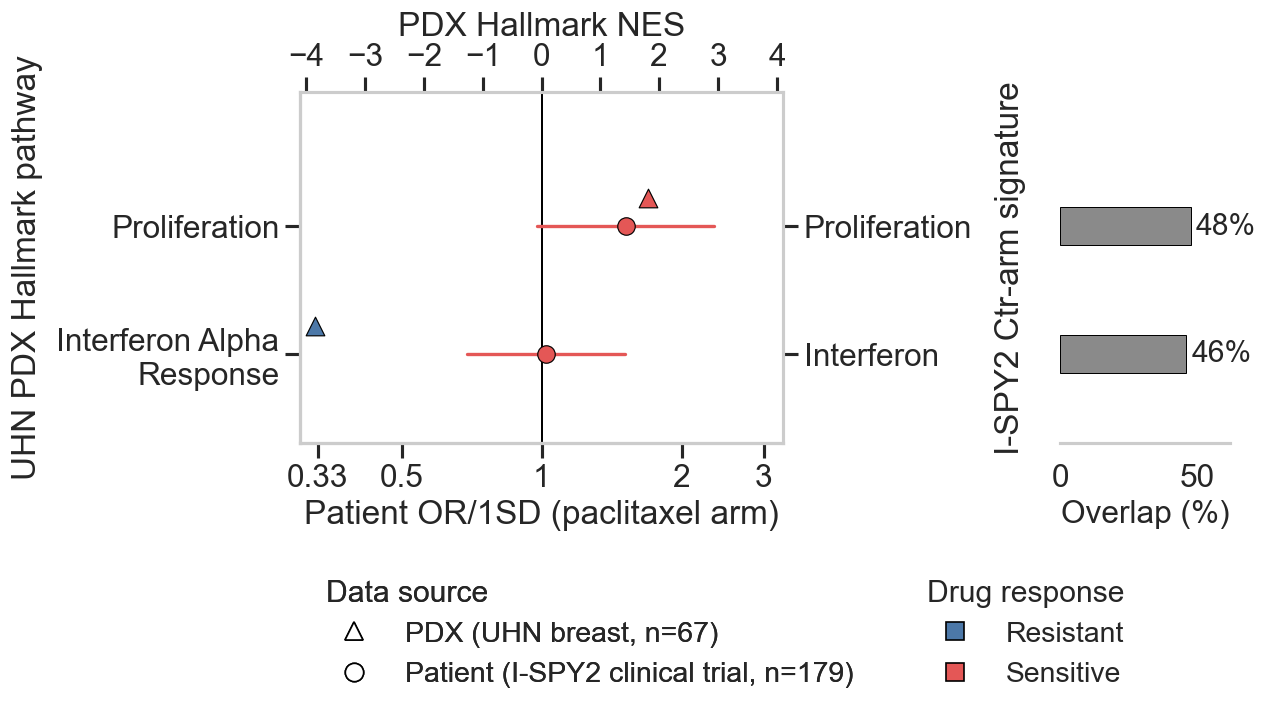

In [7]:
PDX_SHORT_LABELS = {
    PROLIF_LABEL: "Proliferation",
    "Interferon Alpha Response": "Interferon Alpha\nResponse",
}
ISPY2_SHORT_LABELS = {
    "Module11_Prolif_score": "Proliferation",
    "MP_index_adj*(-1)": "MammaPrint index",
    "STAT1_sig": "STAT1 signal",
    "Module3_IFN_score": "Interferon",
}
# Same binary Resistant/Sensitive palette used elsewhere in this case study
# (PALETTE_BINARY in 3-figures.ipynb: GSEA bars, feature-importance bars).
DIRECTION_COLORS = {"Resistant": "#4C78A8", "Sensitive": "#E45756"}

FONT_AXIS_LABEL = 20
FONT_TICK = 19
FONT_LEGEND = 17
FONT_LEGEND_TITLE = 18
FONT_BAR_LABEL = 18

plot_df = comparison_df.copy()
y = np.arange(len(plot_df))[::-1]

# Height scales with the number of rows actually plotted (originally tuned for
# 3 rows; now typically fewer), rather than a fixed guess -- avoids excess
# whitespace when a pathway drops out (e.g. Interferon Gamma Response above).
fig_height = max(3.4, 1.9 + 0.95 * len(plot_df))
fig = plt.figure(figsize=(10.0, fig_height))
gs = fig.add_gridspec(1, 2, width_ratios=[1.7, 0.6], wspace=0.85)
ax_or = fig.add_subplot(gs[0, 0])
ax_overlap = fig.add_subplot(gs[0, 1], sharey=ax_or)
ax_nes = ax_or.twiny()  # shares the y-axis; own x-axis, ticks placed on top by default

# Symmetric ranges around each axis's own null value -> nulls land on the same pixel column
# 4.1, not 3.7: Interferon Alpha Response's NES is -3.85 under limma moderated-t
# ranking (was -3.52 under Welch's t, which is why this was 3.7 before that), so
# the range needs to clear -3.85 with margin -- same clipping failure mode each
# time the ranking statistic changes and this isn't re-checked.
NES_HALF_RANGE = 4.1
OR_RANGE_FACTOR = 3.3  # bottom axis spans (1/factor, factor)
ax_nes.set_xlim(-NES_HALF_RANGE, NES_HALF_RANGE)
ax_or.set_xscale("log")
ax_or.grid(False)
ax_nes.grid(False)
ax_or.set_xlim(1 / OR_RANGE_FACTOR, OR_RANGE_FACTOR)

# I-SPY2 (patient): circle + 95% CI, on the bottom (OR, log-scale) axis -- colored by
# which side of OR=1 this marker itself falls on (its own direction, not the "call").
for yi, (_, row) in zip(y, plot_df.iterrows()):
    color = DIRECTION_COLORS[row["ISPY2_direction"]]
    ax_or.plot([row["OR_ci_lo"], row["OR_ci_hi"]], [yi, yi], color=color, linewidth=2.0, zorder=2)
    ax_or.scatter(row["OR"], yi, marker="o", s=110, color=color, edgecolor="black",
                  linewidth=0.7, zorder=3, label="_nolegend_")

# PDX: triangle, on the top (NES, linear) axis -- colored by its own direction too, so a
# row where triangle and circle share a color is concordant, and differing colors is
# discordant -- readable without a separate "call" legend. Offset slightly above the row
# center so it doesn't visually sit on top of the I-SPY2 circle when they land near the same x.
for yi, (_, row) in zip(y, plot_df.iterrows()):
    color = DIRECTION_COLORS[row["PDX_direction"]]
    ax_nes.scatter(row["PDX_NES"], yi + 0.22, marker="^", s=125, color=color, edgecolor="black",
                   linewidth=0.7, zorder=4, label="_nolegend_")

ax_or.axvline(1, color="black", linewidth=1.2, zorder=1)  # shared null: OR=1 / NES=0

ax_or.set_xlabel("Patient OR/1SD (paclitaxel arm)", fontsize=FONT_AXIS_LABEL)
ax_nes.set_xlabel("PDX Hallmark NES", fontsize=FONT_AXIS_LABEL)

# Explicit "nice" OR tick values -- the default log-scale locator only places a major
# tick at powers of ten, and this range (~0.3-3.3) doesn't span a full decade on either
# side, so only OR=1 would otherwise be labeled (with auto minor labels in sci. notation).
from matplotlib.ticker import NullFormatter, NullLocator
OR_TICKS = [0.33, 0.5, 1, 2, 3]
ax_or.set_xticks(OR_TICKS)
ax_or.set_xticklabels([str(v) for v in OR_TICKS], fontsize=FONT_TICK)
ax_or.xaxis.set_minor_locator(NullLocator())
ax_or.xaxis.set_minor_formatter(NullFormatter())
ax_nes.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
ax_nes.tick_params(axis="x", labelsize=FONT_TICK)

# Left y-axis: PDX pathway names
ax_or.set_yticks(y)
ax_or.set_yticklabels([PDX_SHORT_LABELS[p] for p in plot_df["PDX_pathway"]], fontsize=FONT_TICK)
ax_or.set_ylim(-0.7, len(plot_df) - 0.3 + 0.35)
ax_or.set_ylabel("UHN PDX Hallmark pathway", fontsize=FONT_AXIS_LABEL, labelpad=8)

# Right y-axis (twinx, same rows): I-SPY2 signature names
ax_ispy2_labels = ax_or.twinx()
ax_ispy2_labels.set_ylim(ax_or.get_ylim())
ax_ispy2_labels.set_yticks(y)
ax_ispy2_labels.set_yticklabels([ISPY2_SHORT_LABELS[b] for b in plot_df["ISPY2_biomarker"]], fontsize=FONT_TICK)
ax_ispy2_labels.spines["top"].set_visible(False)
ax_ispy2_labels.grid(False)

ax_or.spines["top"].set_visible(False)
ax_or.spines["right"].set_visible(False)
ax_nes.spines["right"].set_visible(False)
ax_nes.spines["bottom"].set_visible(False)
ax_nes.spines["left"].set_visible(False)

# Third panel: gene-level overlap (%) between the PDX leading-edge genes and the
# I-SPY2 signature actually used for that row -- the evidence behind the mapping.
ax_overlap.barh(y, plot_df["gene_overlap_frac"] * 100, height=0.3, color="#8A8A8A",
                edgecolor="black", linewidth=0.6, zorder=2)
for yi, frac in zip(y, plot_df["gene_overlap_frac"]):
    ax_overlap.text(frac * 100 + 2, yi, f"{frac * 100:.0f}%", va="center", fontsize=FONT_BAR_LABEL)
ax_overlap.set_xlim(0, 62)
ax_overlap.set_xlabel("Overlap (%)", fontsize=FONT_AXIS_LABEL - 1)
ax_overlap.tick_params(axis="both", labelsize=FONT_TICK)
ax_overlap.tick_params(axis="y", left=False, labelleft=False, right=False, labelright=False)
ax_overlap.spines["top"].set_visible(False)
ax_overlap.spines["right"].set_visible(False)
ax_overlap.spines["left"].set_visible(False)
ax_overlap.grid(False)
ax_overlap.set_axisbelow(True)

plt.tight_layout()

# Legends are placed *after* tight_layout so we can read back the actual pixel position
# of the plot's left border and of x=0 (the shared null line) and anchor both legends to
# those exact points, rather than guessing fractional offsets.
fig.canvas.draw()

# Measured, not guessed: read back the actual rendered right edge of the widest
# right-side tick label and place "I-SPY2 Ctr-arm signature" just past it, in that
# axes' own fraction coordinates. Robust to font-size/figure-width changes, unlike a
# fixed labelpad guess (which kept over/under-shooting as those changed).
renderer = fig.canvas.get_renderer()
max_ticklabel_right = max(
    label.get_window_extent(renderer=renderer).x1
    for label in ax_ispy2_labels.get_yticklabels()
)
ispy2_label_x = fig.transFigure.inverted().transform((max_ticklabel_right, 0))[0] + 0.045
# Place once at a guessed y, measure its actual rendered extent, then correct so its
# vertical center lands on the main axes' vertical center -- exact regardless of how
# long the text or how large the font, rather than guessing the offset.
ispy2_label = fig.text(ispy2_label_x, ax_or.get_position().y0, "I-SPY2 Ctr-arm signature",
                        rotation=90, rotation_mode="anchor", va="bottom", ha="center",
                        fontsize=FONT_AXIS_LABEL)
fig.canvas.draw()
label_bbox = ispy2_label.get_window_extent(renderer=fig.canvas.get_renderer())
label_bbox = label_bbox.transformed(fig.transFigure.inverted())
target_center_y = sum(ax_or.get_position().extents[1::2]) / 2
current_center_y = (label_bbox.y0 + label_bbox.y1) / 2
ispy2_label.set_position((ispy2_label_x, ax_or.get_position().y0 + (target_center_y - current_center_y)))

plot_left_fig = ax_or.get_position().x0
zero_x_display = ax_nes.transData.transform((0, 0))[0]
zero_x_fig = fig.transFigure.inverted().transform((zero_x_display, 0))[0]
# Measured, not a fixed fraction: a fixed fractional offset (the old 0.14) represents
# a smaller absolute gap once fig_height shrinks (fewer rows), which collided with
# the x-axis label -- so measure that label's actual rendered bottom edge and place
# the legend a fixed absolute gap below it instead, robust to fig_height changes.
fig.canvas.draw()
xlabel_bbox = ax_or.xaxis.label.get_window_extent(renderer=fig.canvas.get_renderer())
xlabel_bbox = xlabel_bbox.transformed(fig.transFigure.inverted())
legend_y = xlabel_bbox.y0 - 0.05

shape_handles = [
    plt.Line2D([0], [0], marker="^", color="none", markerfacecolor="white", markeredgecolor="black",
               markersize=11, label="PDX (UHN breast, n=67)"),
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black",
               markersize=11, label="Patient (I-SPY2 clinical trial, n=179)"),
]
color_handles = [
    plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=c, markeredgecolor="black",
               markersize=11, label=label)
    for label, c in DIRECTION_COLORS.items()
]
legend1 = fig.legend(handles=shape_handles, loc="upper left", frameon=False, fontsize=FONT_LEGEND,
                      bbox_to_anchor=(plot_left_fig, legend_y), title="Data source",
                      title_fontsize=FONT_LEGEND_TITLE, alignment="left")
fig.add_artist(legend1)

# "Drug response" targets the x=0 null line, but if "Data source" renders wide enough
# (e.g. at a bigger font) to reach past that point, push right just enough to clear it
# instead of overlapping -- robust to font-size changes rather than a fixed offset.
fig.canvas.draw()
legend1_bbox = legend1.get_window_extent(renderer=fig.canvas.get_renderer())
legend1_bbox = legend1_bbox.transformed(fig.transFigure.inverted())
direction_x = max(zero_x_fig + 0.05, legend1_bbox.x1 + 0.03)

fig.legend(handles=color_handles, loc="upper left", frameon=False, fontsize=FONT_LEGEND,
           bbox_to_anchor=(direction_x, legend_y), title="Drug response",
           title_fontsize=FONT_LEGEND_TITLE, alignment="left")

savefig("ispy2_validation_forest")
plt.show()